In [1]:
from copy import deepcopy

import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['font.family']= 'open sans'
from matplotlib.colors import LogNorm

from scipy.optimize import least_squares
from scipy.stats import gaussian_kde

from rdn.validation import Simulation
from rdn.defaults import pardict_from_result
from rdn.fitting.models import LocalGaussModelTilde


Set up the model parameters

In [2]:
model = LocalGaussModelTilde()

model_p_dict = pardict_from_result(
    'output/multi_fitting/Multi_LocalGaussModelTilde/NLLAdast/1_3_5_7_Spine_data_fides_1200.hdf5', 
    Chi=1, dendrite_length=1000, N_mean=5000, run_index=0)

simulation_time = 40
spine_number = 200
inter_spine_distance = 1

# Usual accounting for shorter dendrite
model_p_dict['Pi'] /= 10

# As discussed
model_p_dict['tau_N'] *= 2
model_p_dict['tau_K'] *= 2


This problem is not to be used without a separately created objective.



Basal K distribution:
- Sample size: 59
- Mean: 4306.707120831921 +- 3034.7652938979772
- Anderson test on log: AndersonResult(statistic=np.float64(0.5220797444867884), critical_values=array([0.554, 0.623, 0.742, 0.861, 1.021]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(8.166348968661676), scale=np.float64(0.6403989835907568))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

Basal N distribution:
- Sample size: 58
- Mean: 8486.0741933069 +- 5297.8956769692495
- Anderson test on log: AndersonResult(statistic=np.float64(0.7266111392522063), critical_values=array([0.553, 0.623, 0.742, 0.861, 1.021]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(8.881617560988888), scale=np.float64(0.5787076967243227))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

Correlation matrix between log K_b and log N_

/home/janko/code/push-pull-code/src/rdn/defaults/pardictfromresult.py:114: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  anderson_res = stats.anderson(log_Xbs)


Import the datasets

In [3]:
bdf = pd.read_csv('data/validation_data/chindemi_data/banerjee.csv')
edf = pd.read_csv('data/validation_data/chindemi_data/egger.csv')
gdf = pd.read_csv('data/validation_data/goda_data/stim_norm_2_vs_base.csv')

Plotting parameters

In [155]:
def model(x, p):
    p = 10**p
    
    return (
        (1 + p[0] * x ** (p[1]-1))
         / (1 + p[2] * x ** p[1]) / p[3]
    )

def residual(p, X, Y):
    return Y - model(X,p)

def normalize(x):
    return x/x.max()


[-1.12235853 -7.38717471  2.50523335 -2.55299642]
[7.54469115e-02 4.10039117e-08 3.20061433e+02 2.79900440e-03]


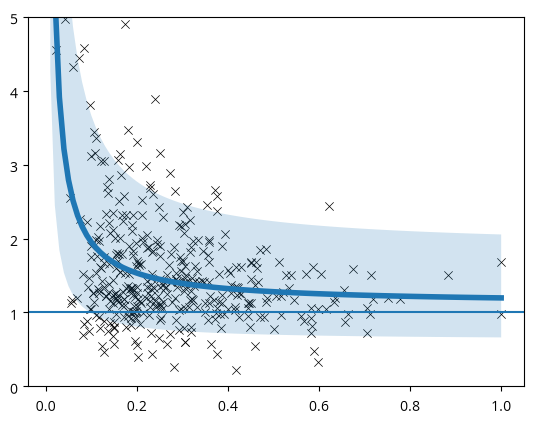

In [170]:
X = np.concat((
    normalize(gdf['base_RID']), (),
    normalize(edf['x']), (),
))

Y = np.concat((
    gdf['norm_2'], (), 
    edf[' y'], (),
))

s_idx = np.argsort(X)
small_idx = np.where(Y<1)
# X = X[small_idx]
# Y = Y[small_idx]
# X = X[s_idx][:-20]
# Y = Y[s_idx][:-20]

# Y = np.log(Y)

xx = np.linspace(0.01,1,100)

p0 = -np.ones(4)*2

res = least_squares(residual, x0=p0, args=(X,Y), loss='linear')

# res.x[2] = -0.5
# res.x[1] = -1

med_res = np.array(res.x).copy()
lq_res = med_res.copy()
hq_res = med_res.copy()

lq_res[0] /= 1.1
lq_res[2] /= 1.1
hq_res[0] *= 1.1
hq_res[2] *= 1.1

plt.scatter(X,Y, c='black', marker='x', lw=0.5)
plt.plot(xx, model(xx, med_res), lw=4)
plt.gca().fill_between(xx, model(xx, lq_res), model(xx, hq_res), alpha=0.2)
# plt.plot(xx, model(xx, lq_res))
# plt.plot(xx, model(xx, hq_res))
plt.gca().axhline(1)
# plt.scatter(xx, model(xx, med_res))
# plt.scatter(xx, model(xx, lq_res))

plt.ylim(0,5)
print(res.x)
print(10**res.x)

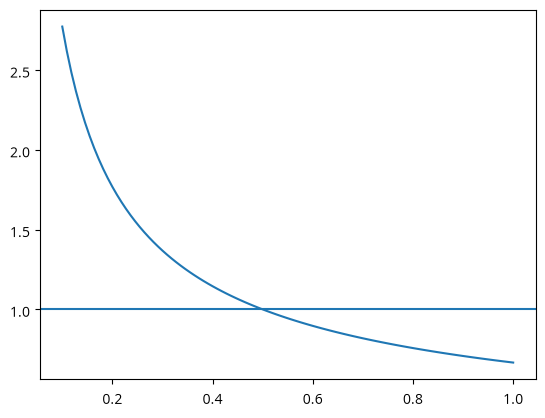

In [100]:
def f(x):
    a = 1
    b = 0.4
    c = 2
    return (
        (1 + a * x ** (b-1))
        / ( 1 + c * x ** b)
    )

x = np.linspace(0.1,1,100)
plt.plot(x, f(x))
plt.gca().axhline(1)

In [ ]:
RHO = 0.83712
VAR_K = 0.34
VAR_N = 0.33
MU_N = 8.88
MU_K = 8.16


def f(x):
    rho = 0.83712457
    var_K 